In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


### Importing some basic libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None
pd.options.display.max_rows = None 

### Loading Dataset

In [3]:
df_train=pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")
df_test=pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv")

# Exporatory Data Analysis

In [4]:
df_train.head()

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,14393,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,Core,CORE,Update,5.0,26,UNKNOWN,0,IS_GENUINE,Retail,0.0,Retail,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,1,4096.0,AllinOne,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,34,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,1,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,Core,CORE,Reset,5.0,26,FullAuto,0,IS_GENUINE,OEM:NONSLP,0.0,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1890776.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,Core,CORE,Upgrade,7.0,30,UNKNOWN,0,IS_GENUINE,OEM:DM,0.0,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4322.0,305245.0,HDD,52804.0,0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,628.0

### 

In [5]:
df_train.shape

(100000, 76)

Dataset Dimensions:
The dataset contains 100,000 rows and 76 columns, indicating a relatively large and complex dataset.

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

# Insights From Data.info()

**Object Columns (28):** These include identifiers and string-based features such as MachineID, ProductName, OSVersion, and date fields (DateAS, DateOS). These may represent categorical data or need conversion (e.g., date columns to datetime).

**Integer Columns (17):** Columns like IsBetaUser, CountryID, and target are stored as integers and likely represent discrete or binary features.
Float Columns (31): Many numerical features are stored as floats (e.g., RealTimeProtectionState, PrimaryDiskCapacityMB), often due to the presence of missing values.

**Missing Data:**
1.Several columns have missing values. For example:
2.RealTimeProtectionState has 66 missing entries.Columns such as AntivirusConfigID, CityID, and IsSystemProtected also have missing values.
This indicates a need for a careful imputation strategy or further investigation into why these values are missing.

In [7]:
df_train.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

# Insights From data.describe()
**Constant Column:**

IsBetaUser is always 0, so it doesn't add any useful information.

**Binary Features:**

Several columns (e.g., IsPassiveModeEnabled, HasTpm, IsSecureBootEnabled) only have 0s and 1s, showing yes/no information.

**Value Ranges:**

RealTimeProtectionState is mostly around 7, but a few values are 0, which might be unusual.
AntivirusConfigID has a very wide range (from 39 to 70490), indicating possible outliers or a skewed distribution.
NumAntivirusProductsInstalled and NumAntivirusProductsEnabled mostly have low numbers, usually 1.

**Binary Features:**

Several columns (e.g., IsPassiveModeEnabled, HasTpm, IsSecureBootEnabled) only have 0s and 1s, showing yes/no information.

**Value Ranges:**

RealTimeProtectionState is mostly around 7, but a few values are 0, which might be unusual.
AntivirusConfigID has a very wide range (from 39 to 70490), indicating possible outliers or a skewed distribution.
NumAntivirusProductsInstalled and NumAntivirusProductsEnabled mostly have low numbers, usually 1.

In [8]:
missing_values = df_train.isna().sum()
missing_values = missing_values[missing_values > 0]  
missing_percentage = (missing_values / len(df_train)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df.sort_values(by='Percentage', ascending=False)
print(missing_df)


                                    Missing Values  Percentage
SMode                                          981       0.981
CityID                                         623       0.623
IsGamer                                        559       0.559
RegionIdentifier                               559       0.559
InternalBatteryNumberOfCharges                 515       0.515
FirmwareManufacturerID                         376       0.376
FirmwareVersionID                              334       0.334
IsFlightsDisabled                              326       0.326
OEMModelID                                     228       0.228
OEMNameID                                      212       0.212
FirewallEnabled                                166       0.166
TotalPhysicalRAMMB                             151       0.151
IsAlwaysOnAlwaysConnectedCapable               134       0.134
OSInstallLanguageID                            113       0.113
SystemVolumeCapacityMB                         110     

# Insights From Missing Values
1. We have >50% missing values in SMode, CityID, IsGamer and RegionIdentifier, so we have to drop these columns as they may not provide useful insights.
2. we have to impute Columns with 1%-8% missing values (ProcessorCoreCount, TotalPhysicalRAMMB, OEMNameID, FirewallEnabled, IsSystemProtected)using median/mode to retain information.


In [9]:
unique_counts = df_train.nunique().sort_values(ascending=False)
print(unique_counts)

MachineID                             99835
SystemVolumeCapacityMB                46188
CityID                                16047
OEMModelID                            15952
FirmwareVersionID                     12299
SignatureVersion                       2735
DateAS                                 2695
AntivirusConfigID                      1976
InternalBatteryNumberOfCharges         1760
ProcessorModelID                       1659
OEMNameID                               837
PrimaryDiskCapacityMB                   398
PrimaryDisplayDiagonalInches            362
OSBuildLab                              281
GeoRegionID                             239
NumericOSVersion                        221
CountryID                               220
OSBuildRevisionOnly                     199
LocaleEnglishNameID                     185
FirmwareManufacturerID                  169
PrimaryDisplayResolutionVertical        131
TotalPhysicalRAMMB                      127
PrimaryDisplayResolutionHorizont

# Insights From Data.nunique()
1. MachineID has 99,835 unique values, meaning it's a unique identifier and should be dropped as it doesn't provide useful insights.

2. IsFlightsDisabled, AutoSampleSubmissionEnabled, and IsBetaUser have only 1 unique value, meaning they provide no useful information and should be dropped.
   
3. Features like  IsPassiveModeEnabled, FirewallEnabled, etc. have only 2 unique values, meaning they are binary and can be kept as is.

In [10]:
df_train.DateAS.head()

0    2018-09-10 10:11:00
1    2018-08-16 00:01:00
2    2018-09-20 23:20:00
3    2018-09-14 00:32:00
4    2018-09-15 19:34:00
Name: DateAS, dtype: object

# Categorizing the features into binary, categorical and numerical features.

In [11]:
# Convert datetime features for both training and test sets
for df in [df_train, df_test]:
    df['DateAS'] = pd.to_datetime(df['DateAS'], errors='coerce')
    df['DateOS'] = pd.to_datetime(df['DateOS'], errors='coerce')
    
    # Extract date-related features (without filling NaNs)
    df['DateAS_year'] = df['DateAS'].dt.year
    df['DateAS_month'] = df['DateAS'].dt.month
    df['DateAS_day'] = df['DateAS'].dt.day

    df['DateOS_year'] = df['DateOS'].dt.year
    df['DateOS_month'] = df['DateOS'].dt.month
    df['DateOS_day'] = df['DateOS'].dt.day

    # Drop the original datetime columns
    df.drop(columns=['DateAS', 'DateOS'],axis=1, inplace=True)

In [12]:
feature_list = df_train.drop(columns=['target']).columns.values  # All features except target
label = ['target']  # Target column


In [13]:
binary_features = df_train[feature_list].nunique(dropna=True)
binary_features = binary_features[binary_features == 2].index.tolist()

# 2️⃣ Separate Binary Features into Numeric & Categorical
binary_numeric_features = [col for col in binary_features if df_train[col].dtype in ['int64', 'float64']]
binary_categorical_features = [col for col in binary_features if df_train[col].dtype == 'object']
df_train[binary_numeric_features] = df_train[binary_numeric_features].astype('Int64')


# 3️⃣ Identify Categorical Features (Objects + Low Unique Integers)
categorical_features = df_train.select_dtypes(include=['object']).columns.drop("MachineID").tolist()
# 4️⃣ Identify Numerical Features (Remove Binary & Categorical)
numerical_features = df_train[feature_list].select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in binary_features]


In [14]:
df_train[binary_categorical_features].dtypes

ProductName     object
DeviceFamily    object
dtype: object

In [15]:
df_train[categorical_features].dtypes

ProductName                 object
EngineVersion               object
AppVersion                  object
SignatureVersion            object
PlatformType                object
Processor                   object
OSVersion                   object
OsPlatformSubRelease        object
OSBuildLab                  object
SKUEditionName              object
MDC2FormFactor              object
DeviceFamily                object
PrimaryDiskType             object
ChassisType                 object
PowerPlatformRole           object
NumericOSVersion            object
OSArchitecture              object
OSBranch                    object
OSEdition                   object
OSSkuFriendlyName           object
OSInstallType               object
AutoUpdateOptionsName       object
OSGenuineState              object
LicenseActivationChannel    object
FlightRing                  object
dtype: object

# Univariate Analysis for Categorical Features

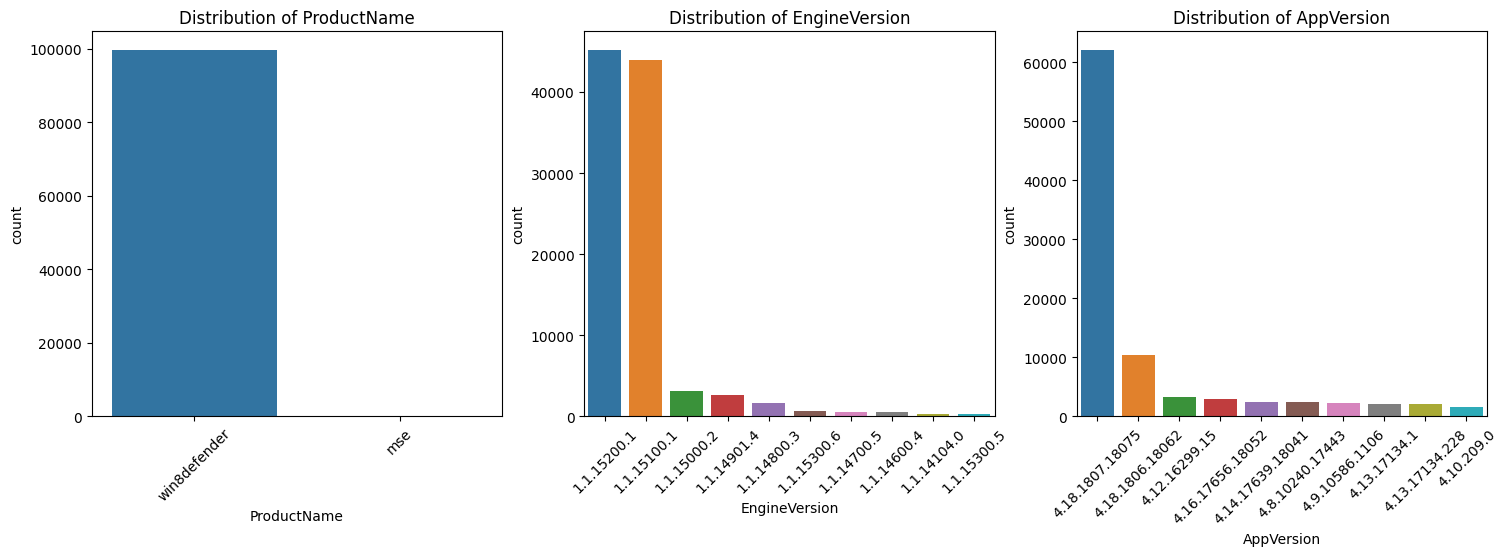

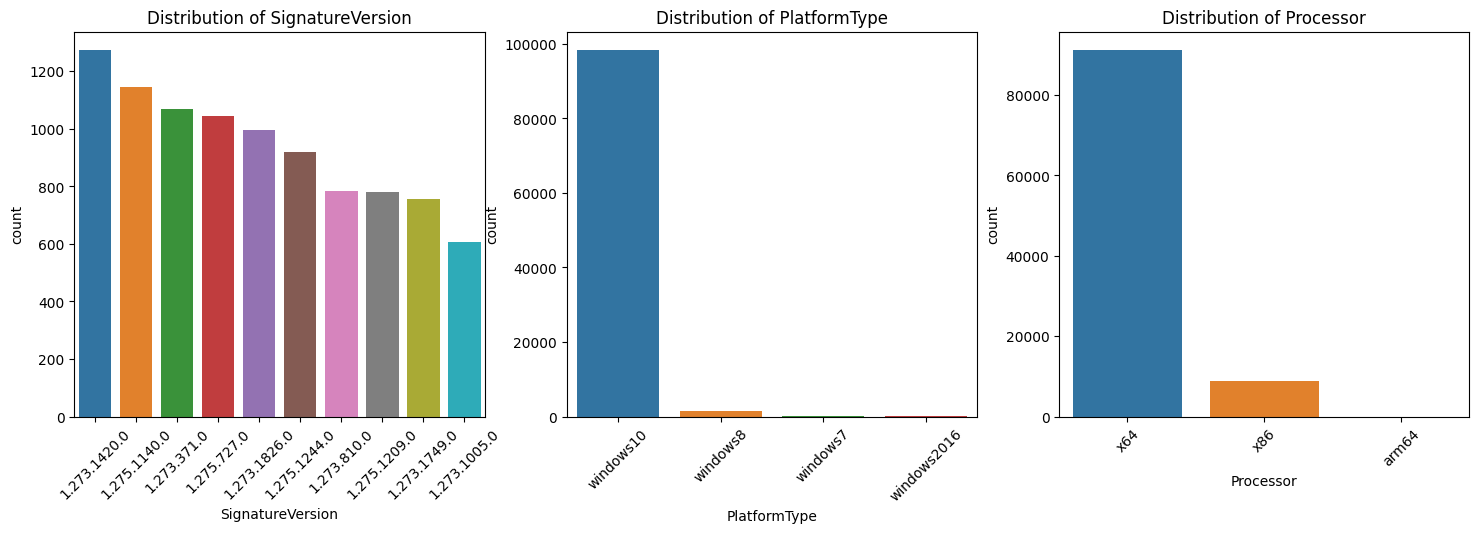

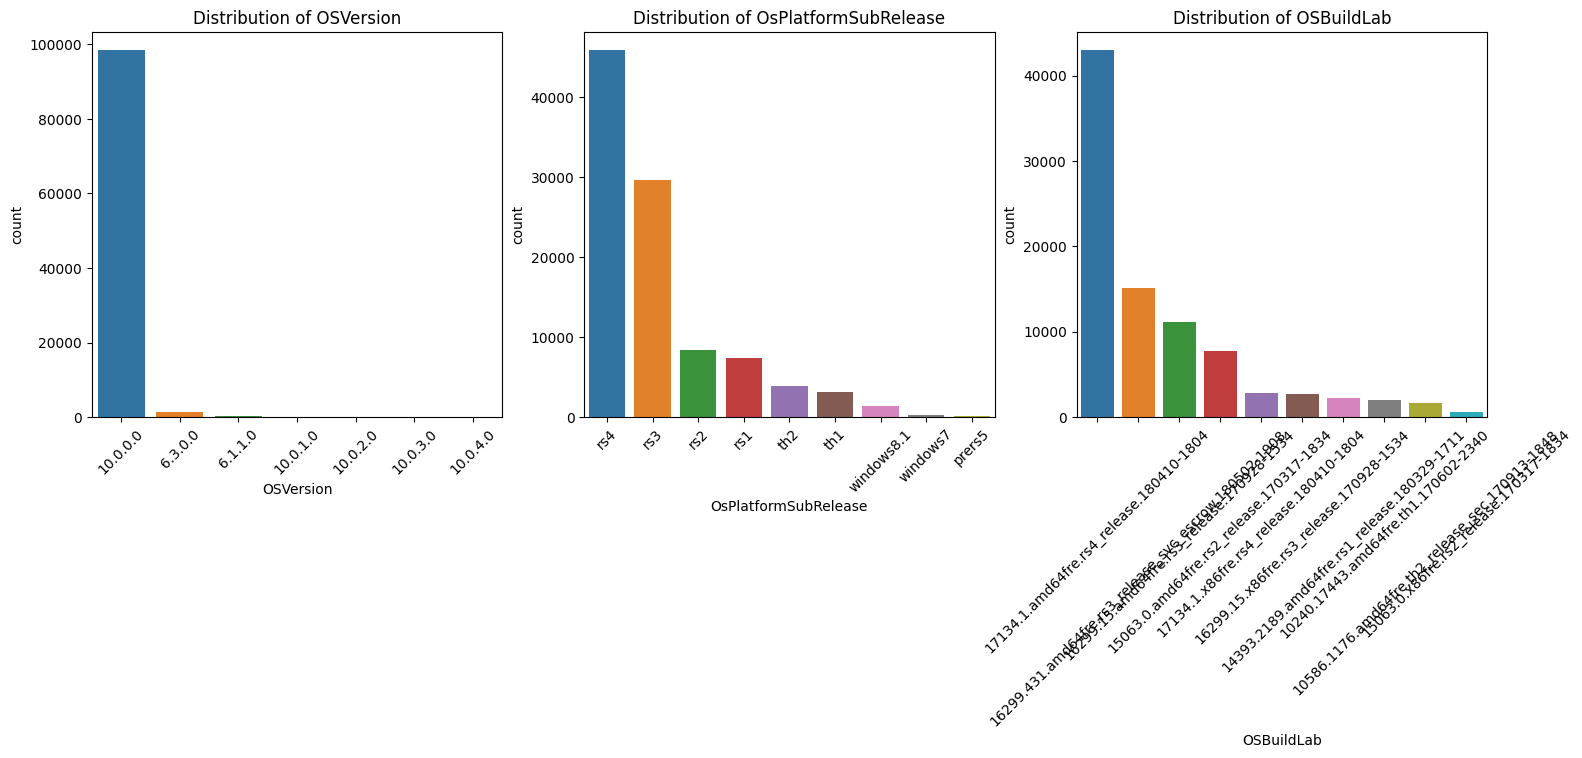

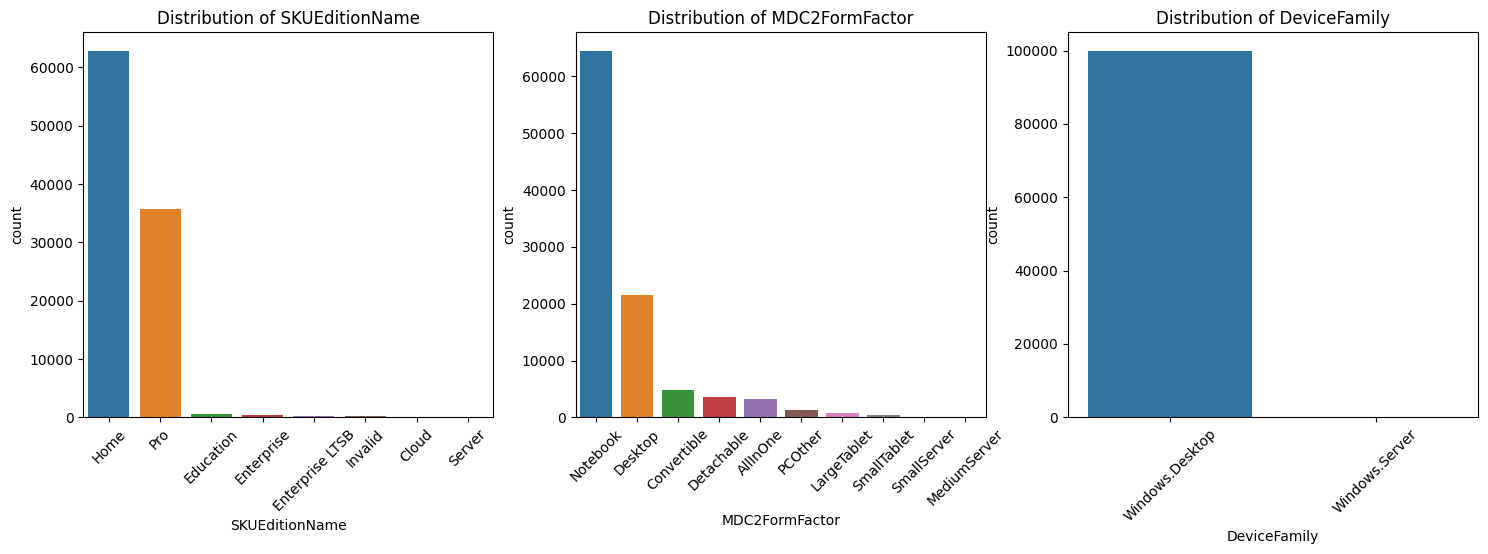

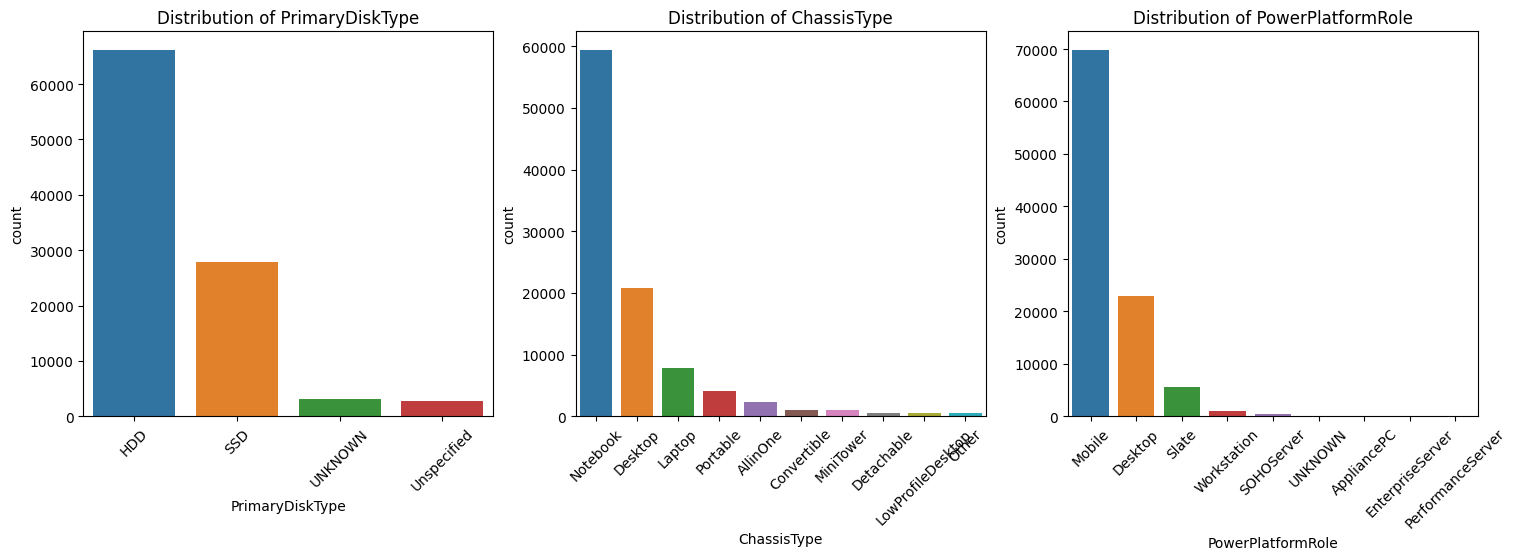

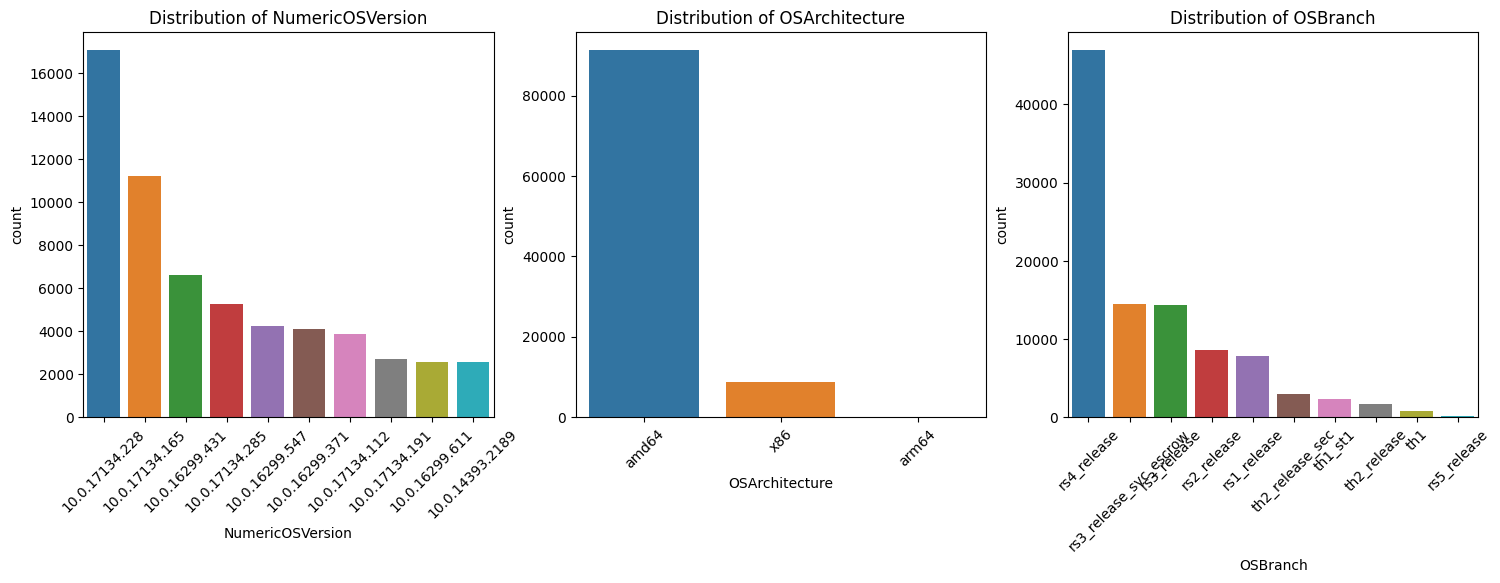

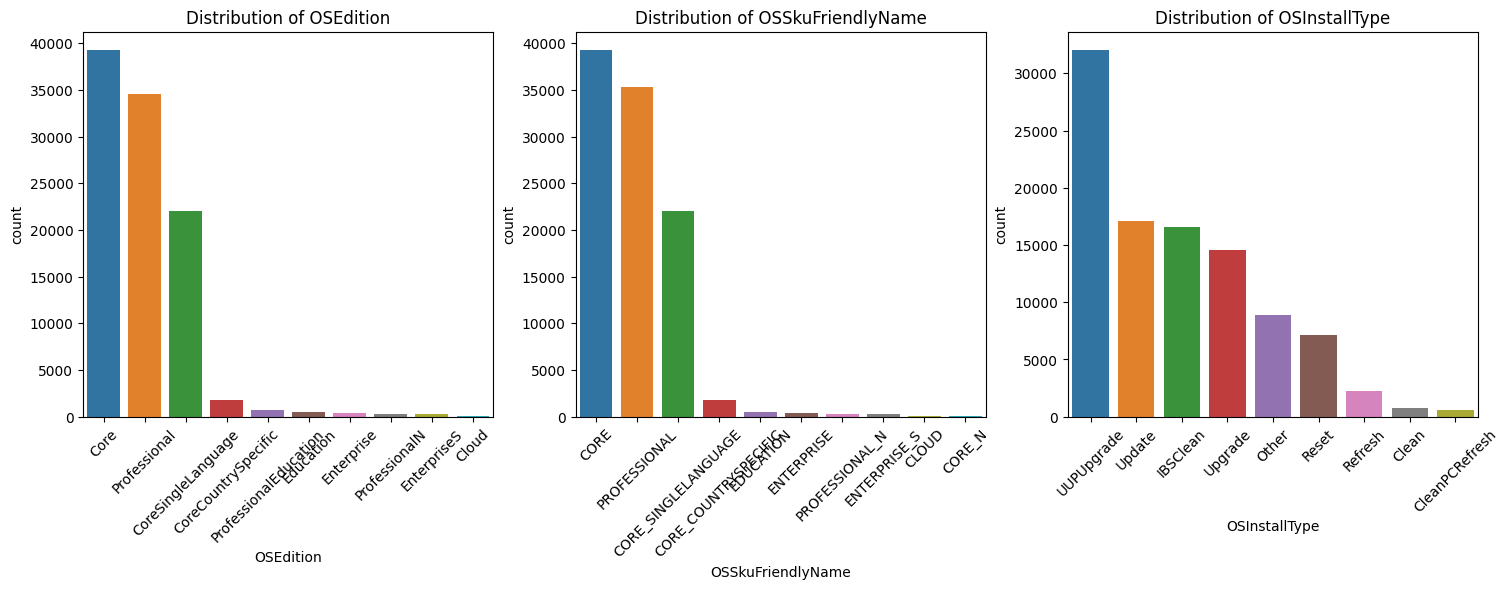

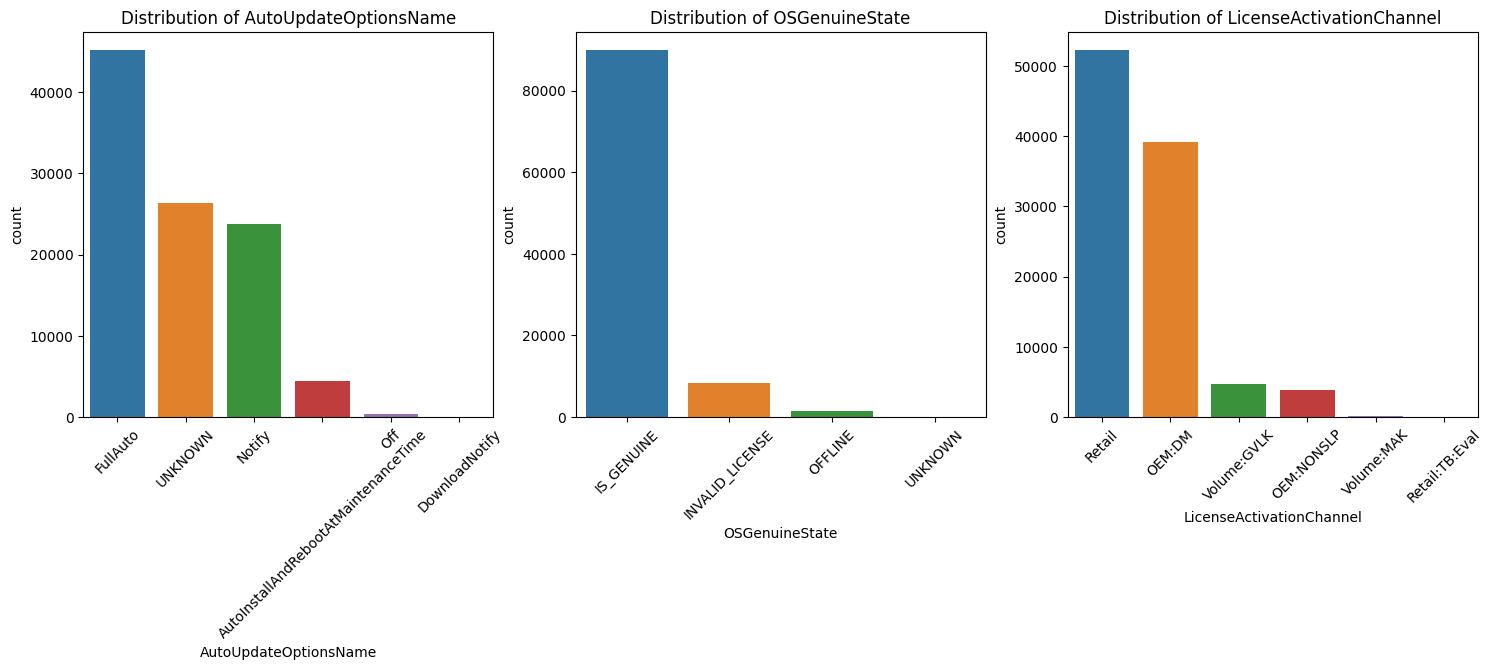

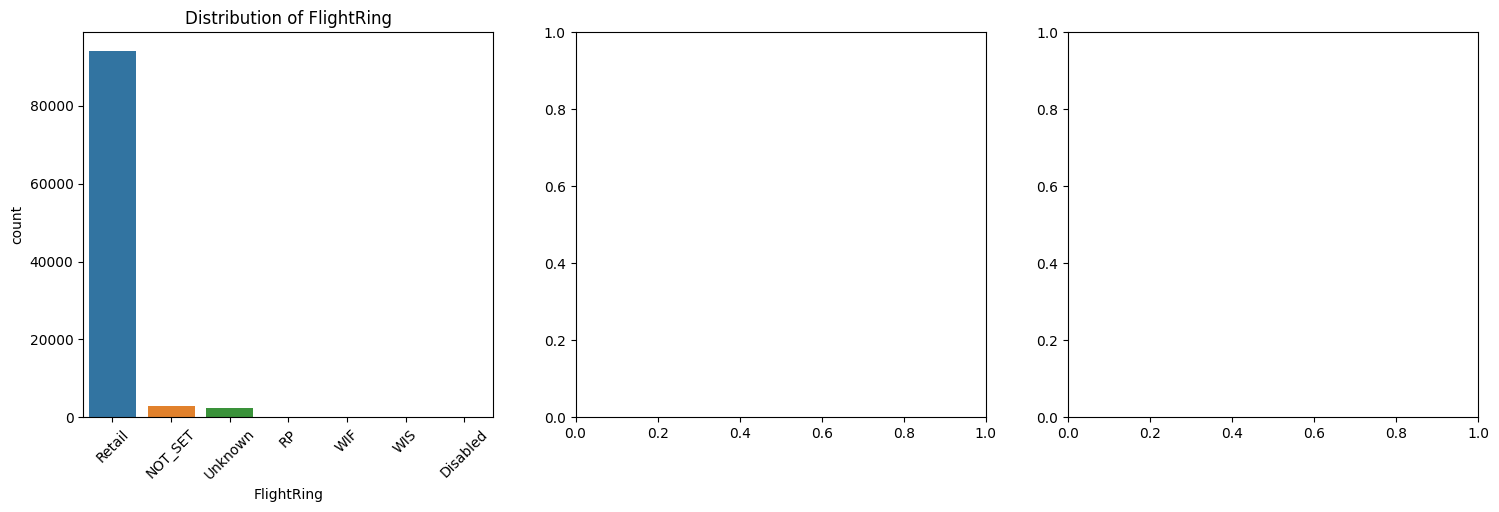

In [16]:
# Plot countplots for categorical features (Top 10 categories)
for i in range(0, len(categorical_features), 3):  
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))  
    
    for j, col in enumerate(categorical_features[i:i+3]): 
        sns.countplot(x=df_train[col], order=df_train[col].value_counts().index[:10], ax=axes[j])
        axes[j].set_title(f"Distribution of {col}")
        axes[j].tick_params(axis='x', rotation=45)  

    plt.show() 

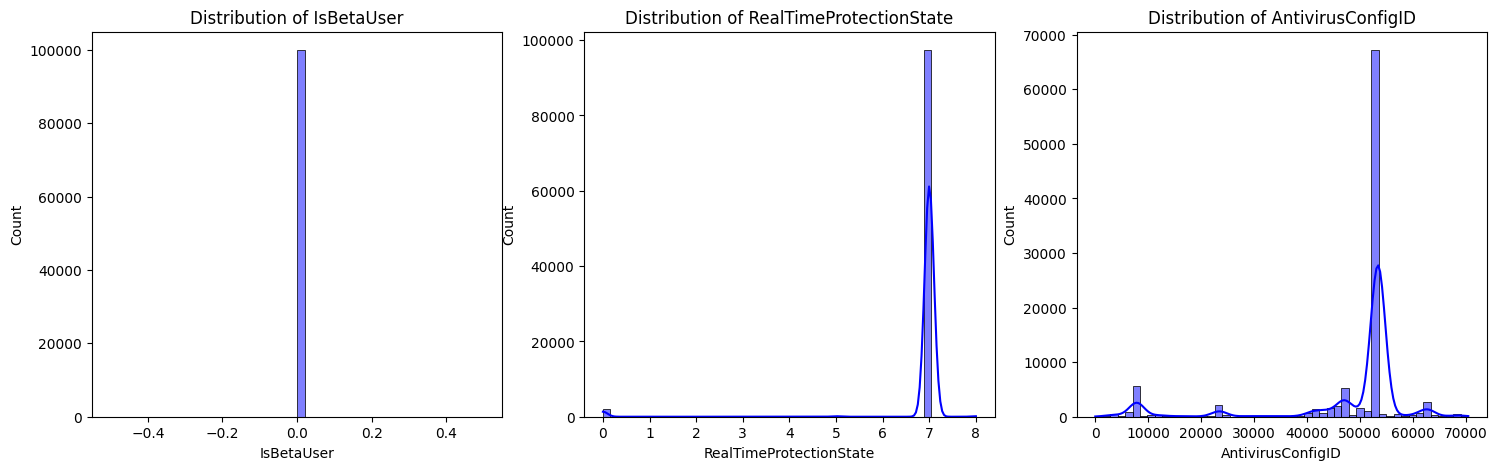

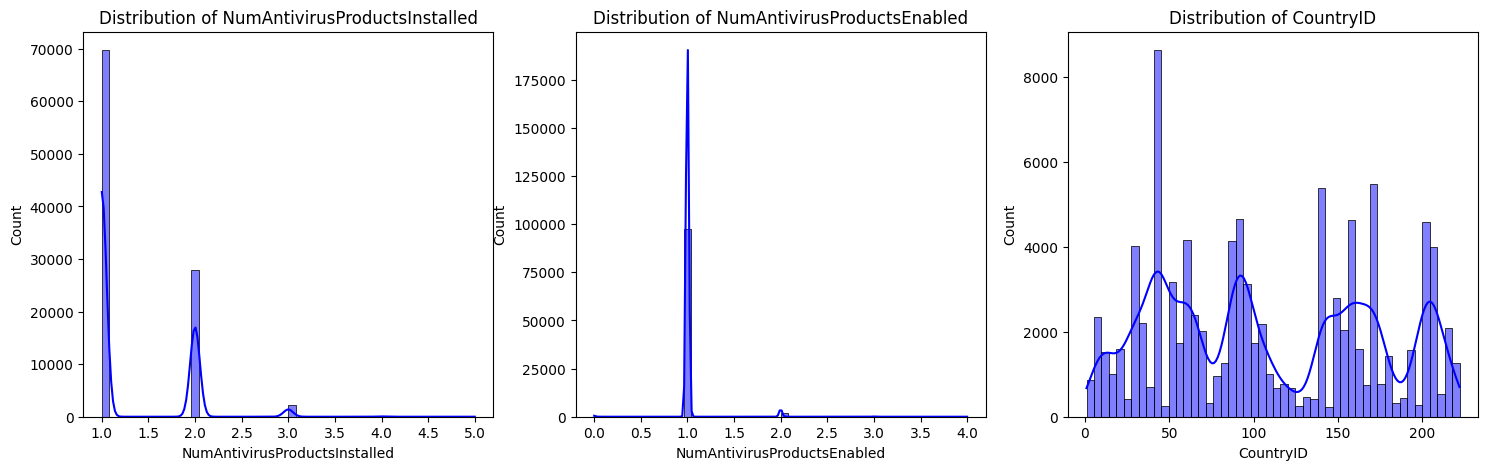

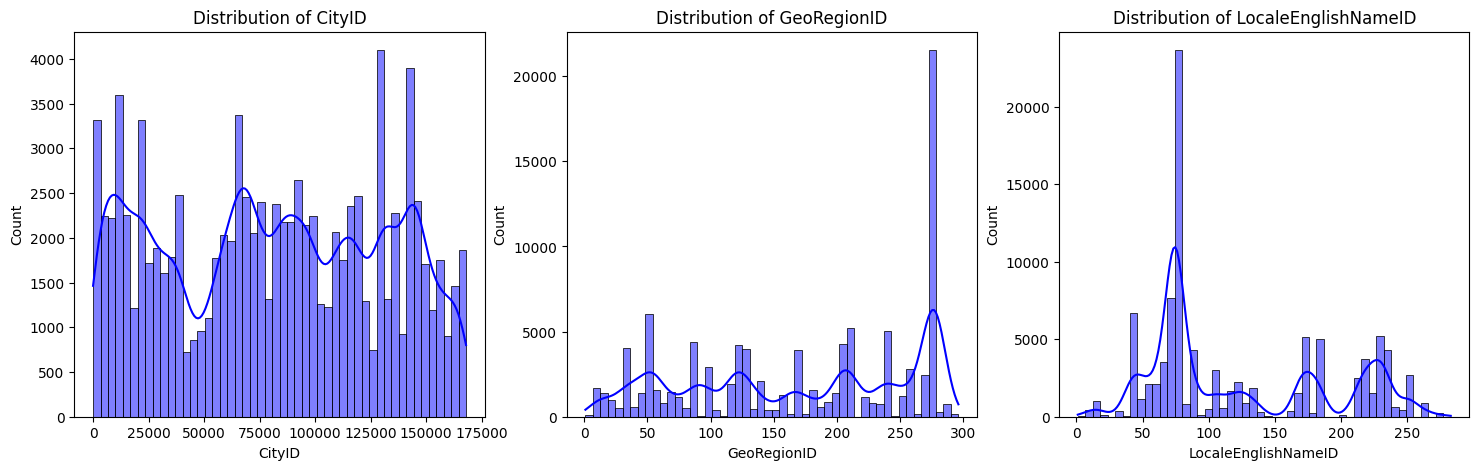

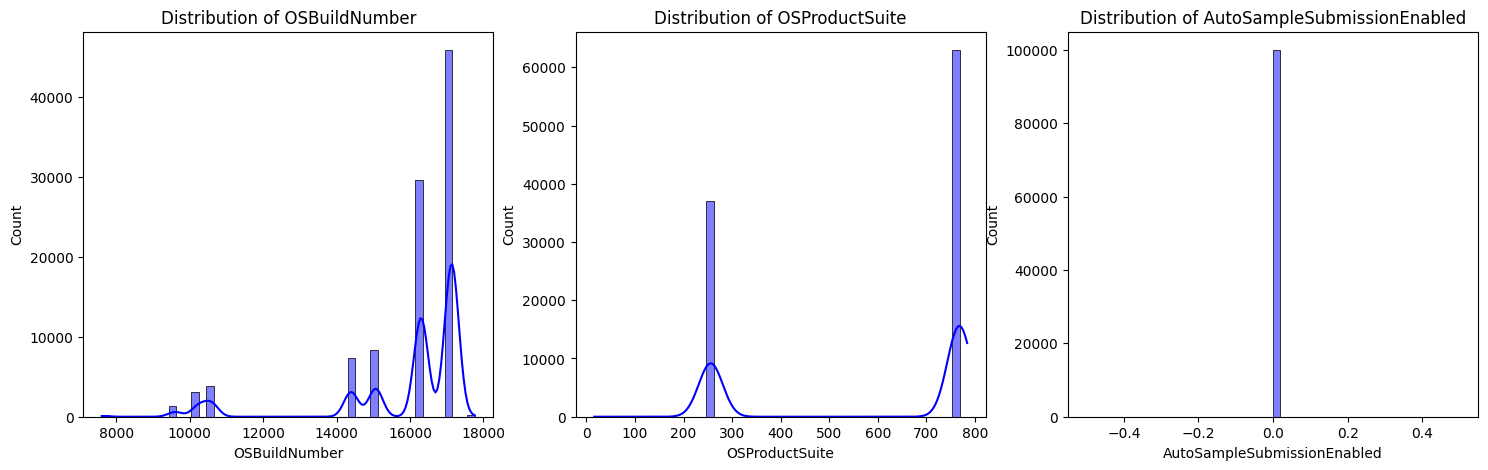

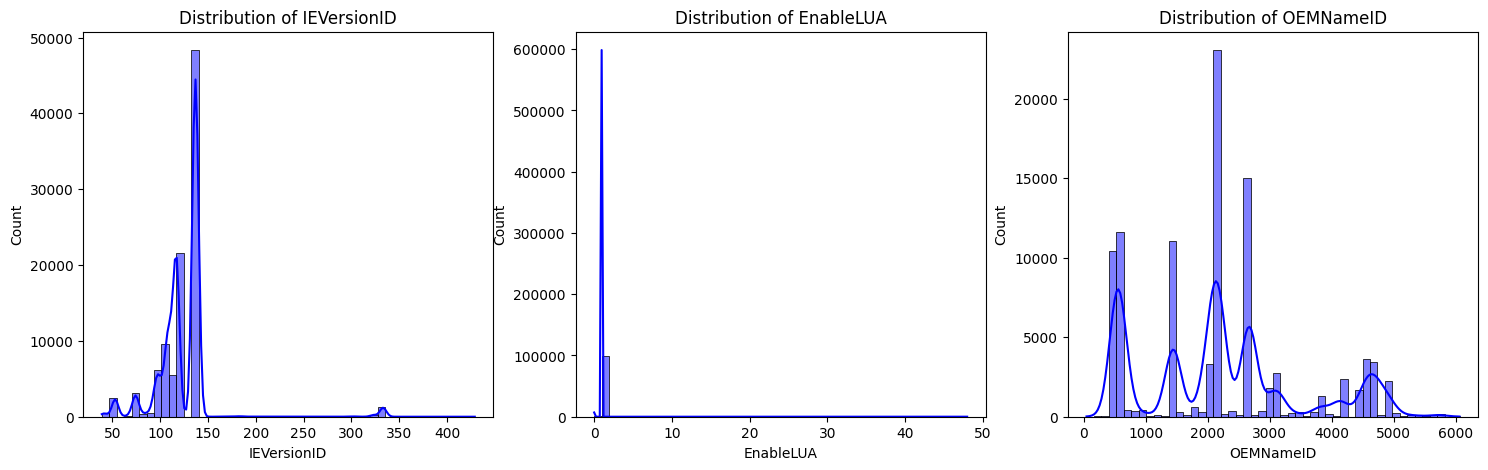

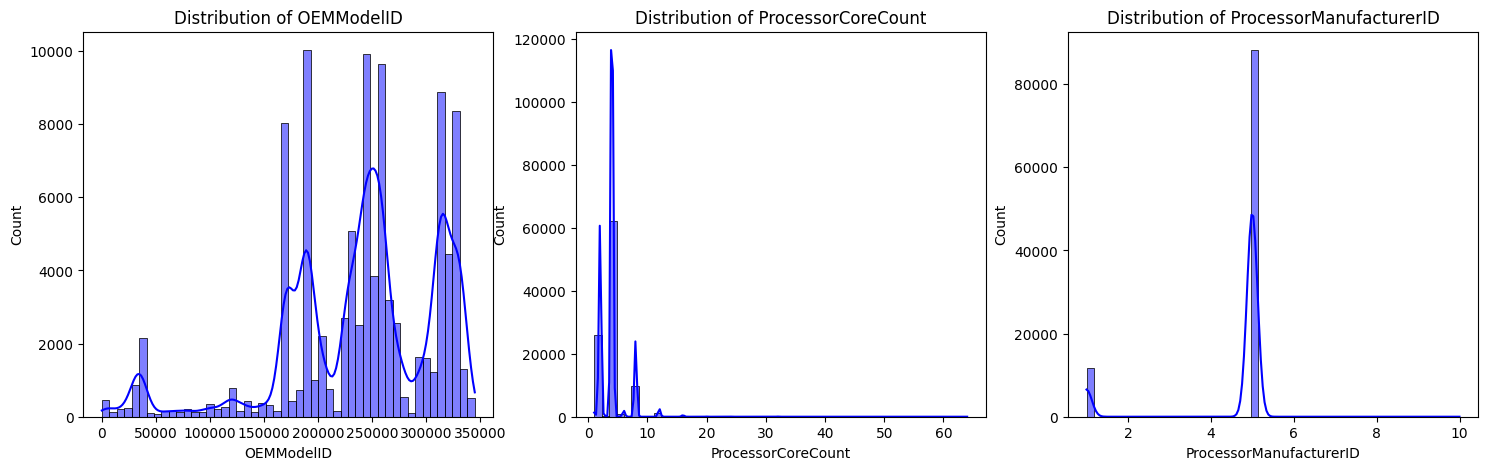

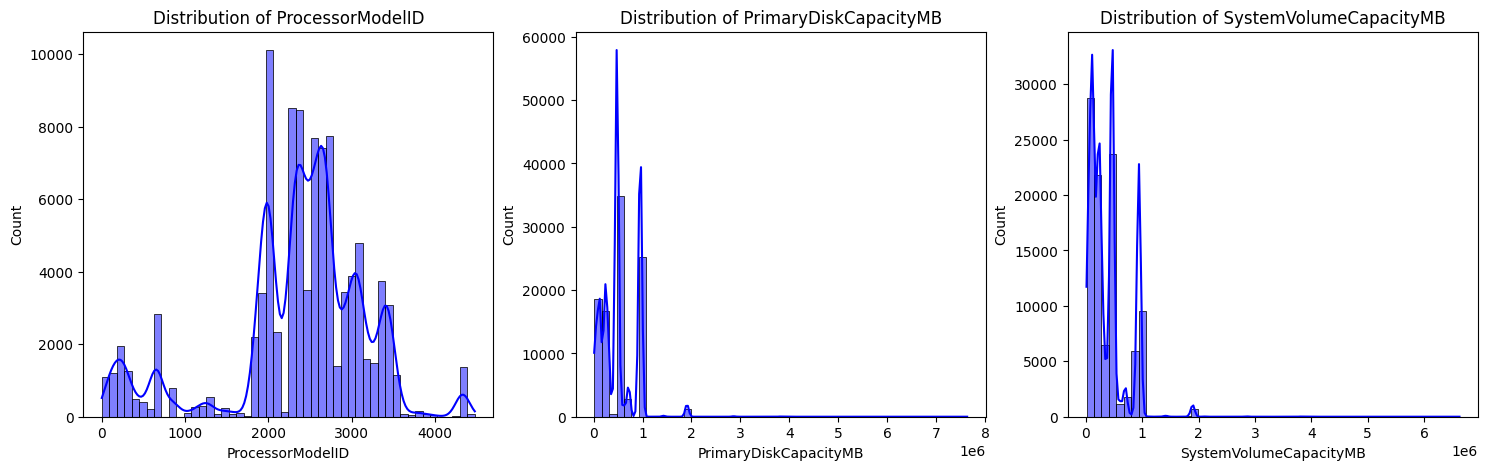

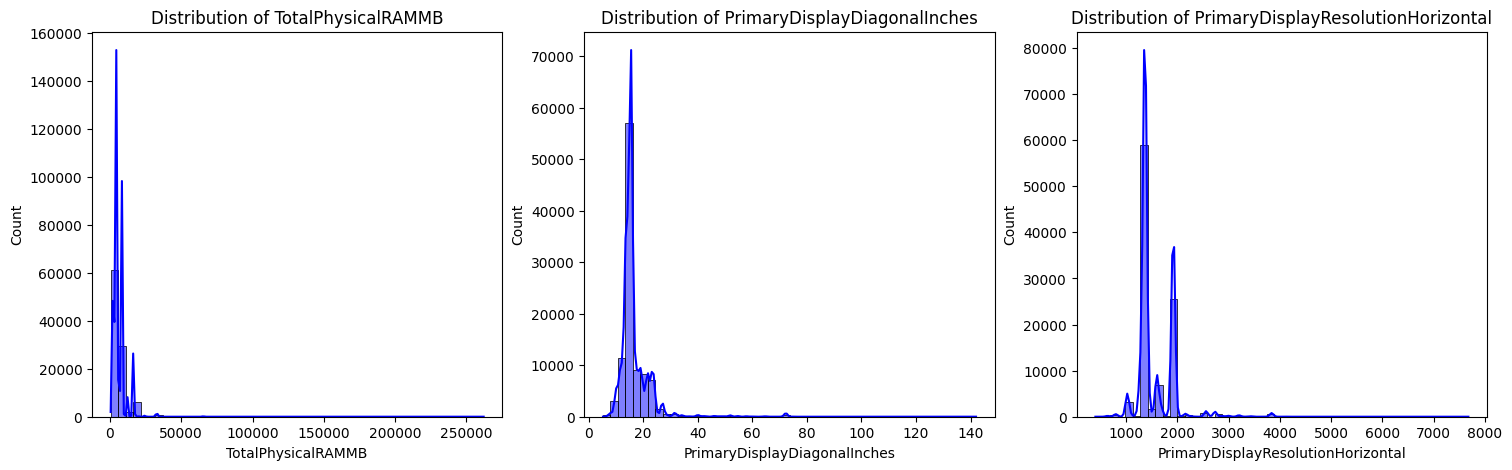

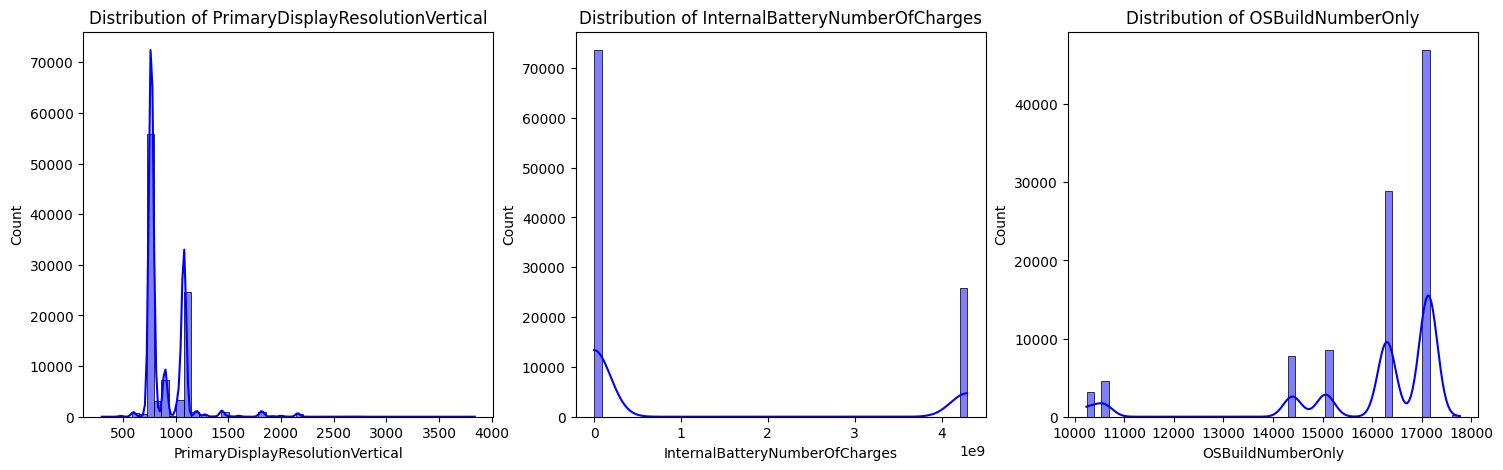

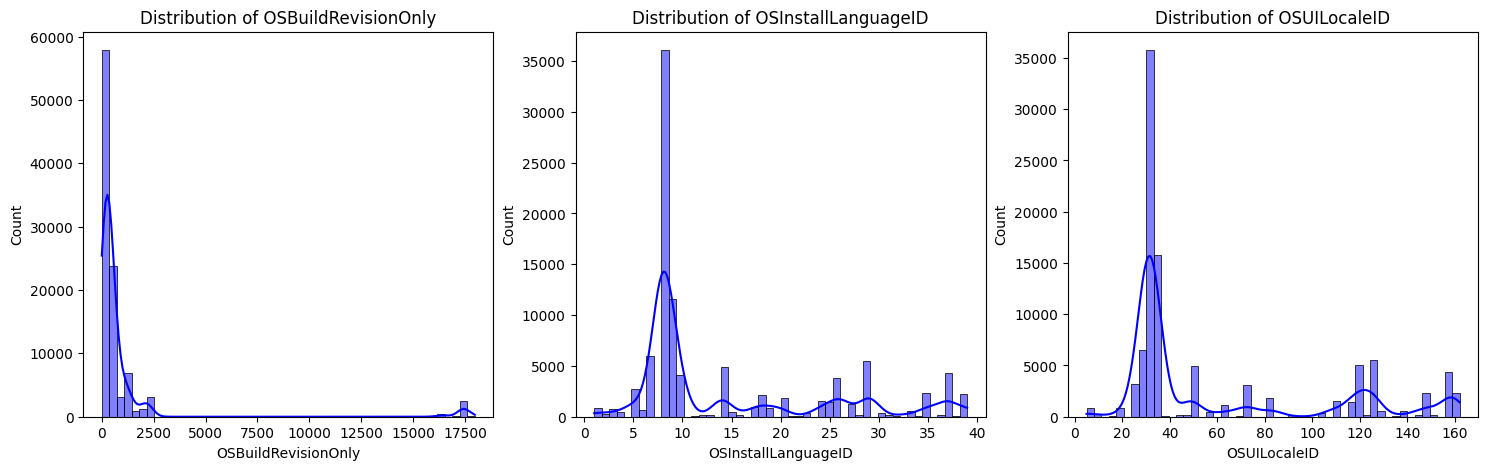

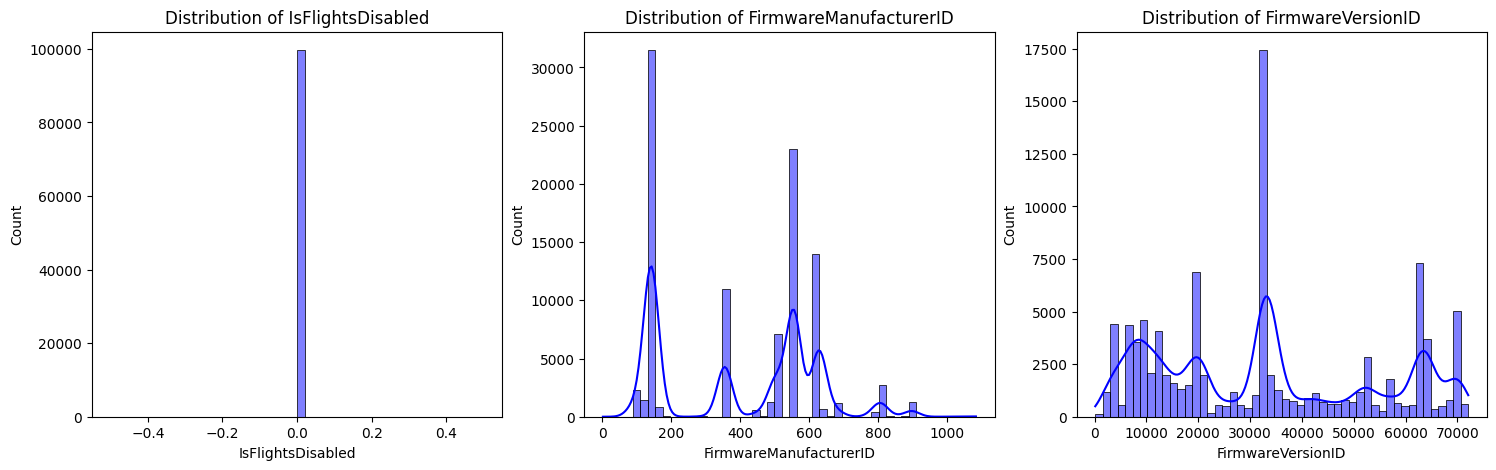

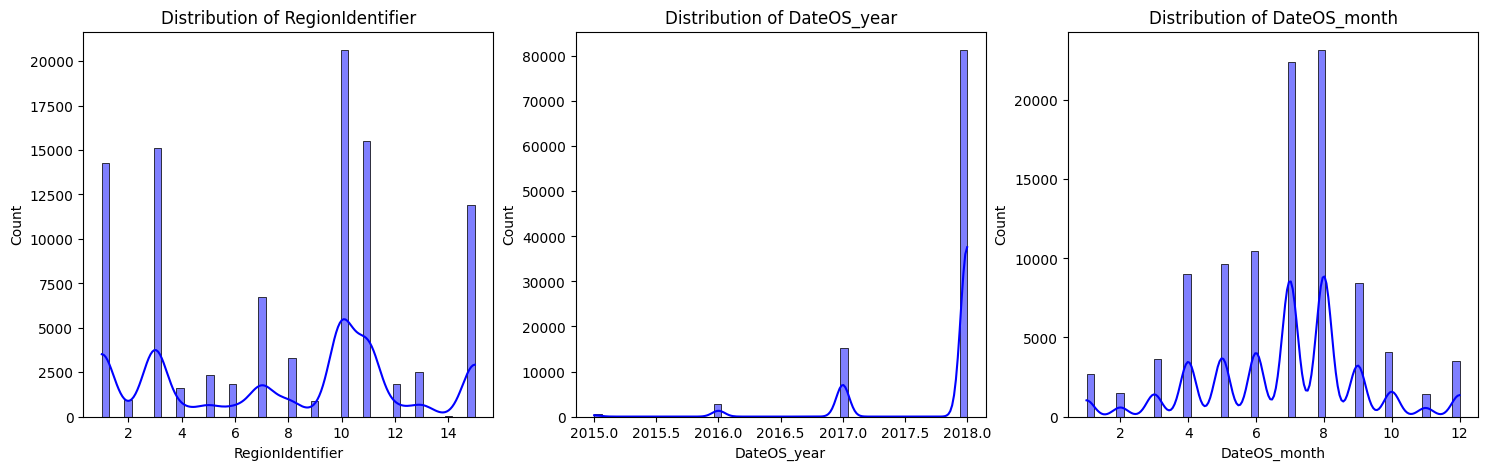

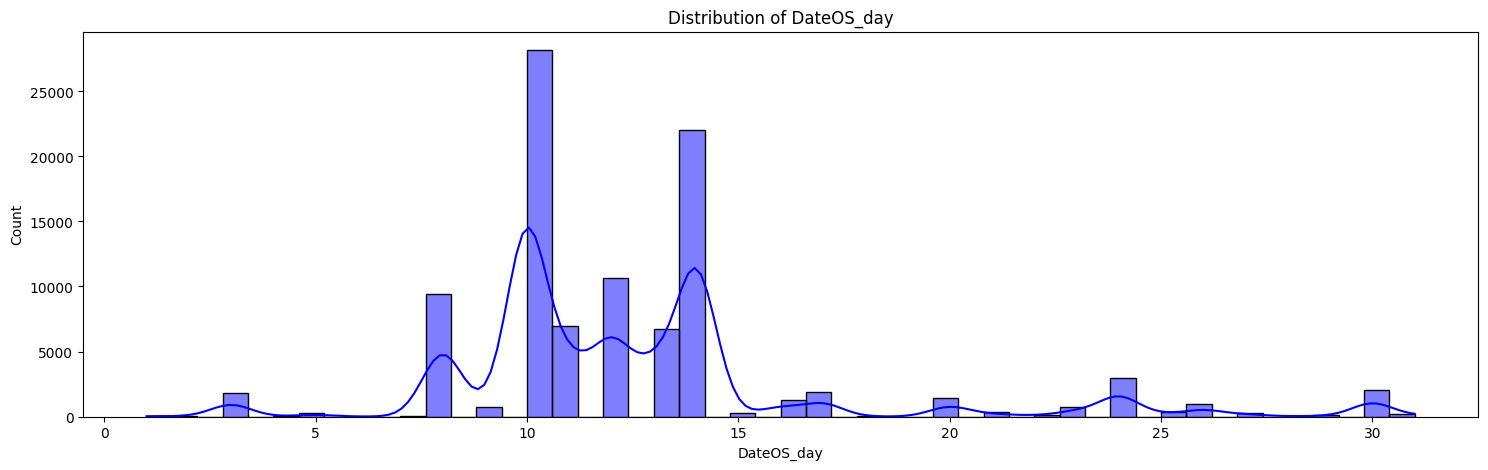

In [17]:
# Plot histograms with KDE for numerical features
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

for i in range(0, len(numerical_features), 3):  
    cols = numerical_features[i:i+3]  # Take 3 columns at a time
    fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))  # Adjust number of subplots
    
    if len(cols) == 1:  # If only 1 column left, axes is not a list
        axes = [axes]  
    
    for j, col in enumerate(cols):  
        sns.histplot(df_train[col].dropna(), bins=50, kde=True, color="blue", ax=axes[j])
        axes[j].set_title(f"Distribution of {col}")

    plt.show()


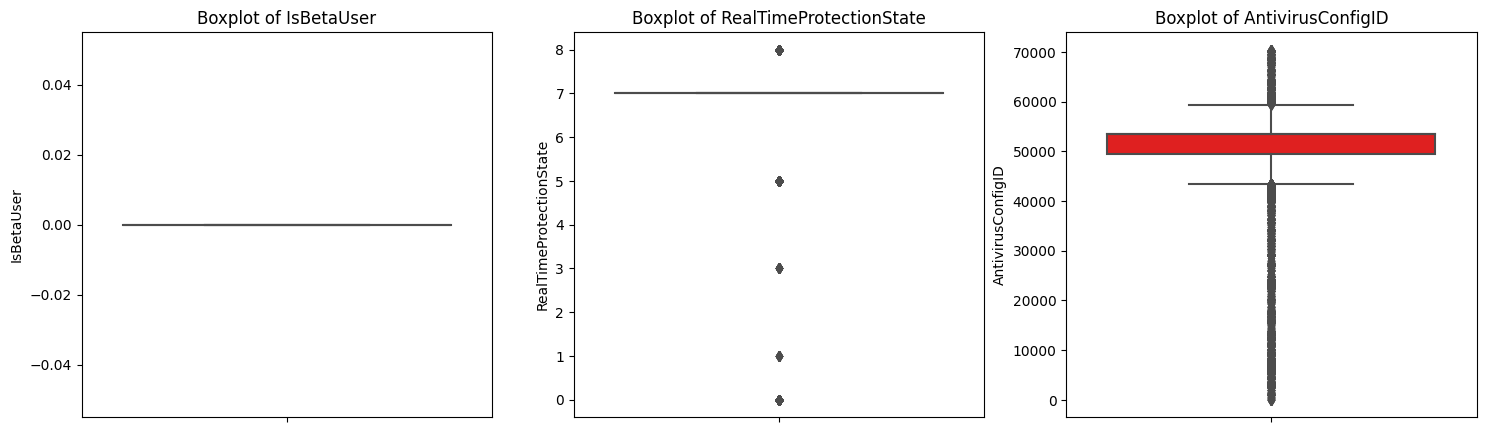

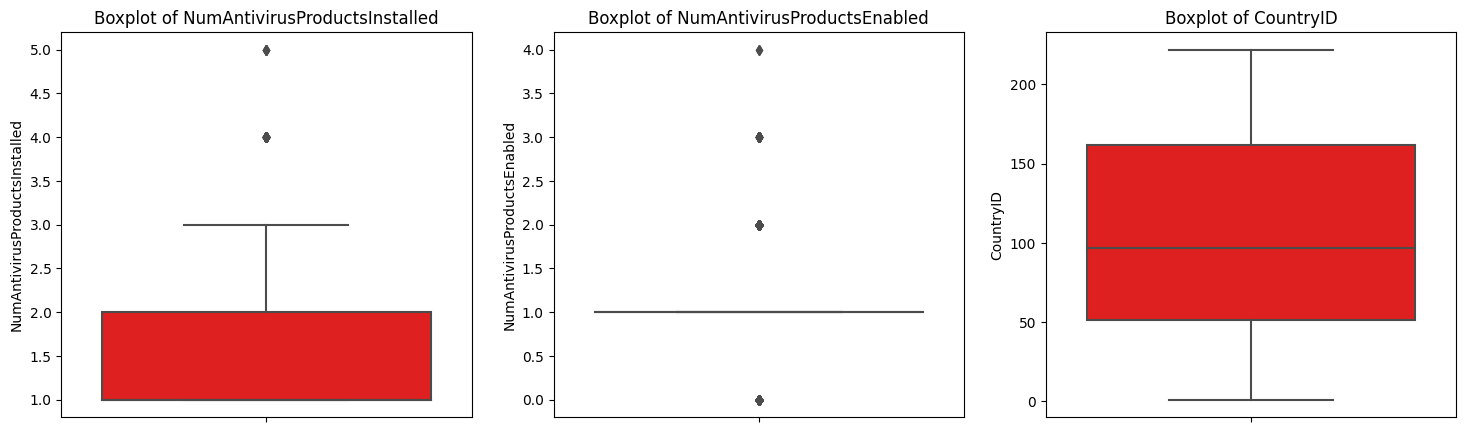

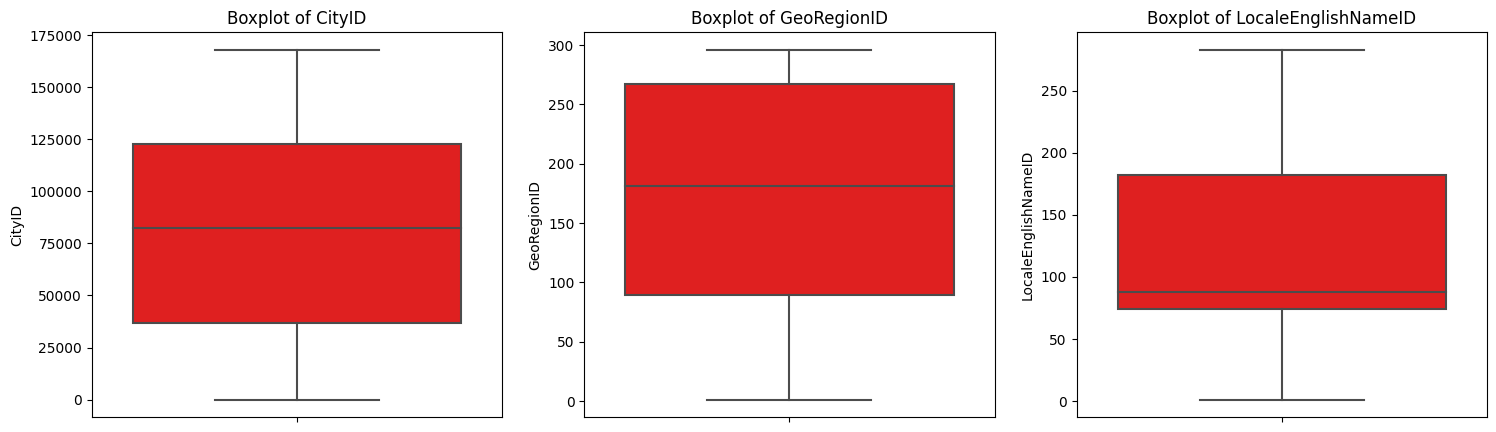

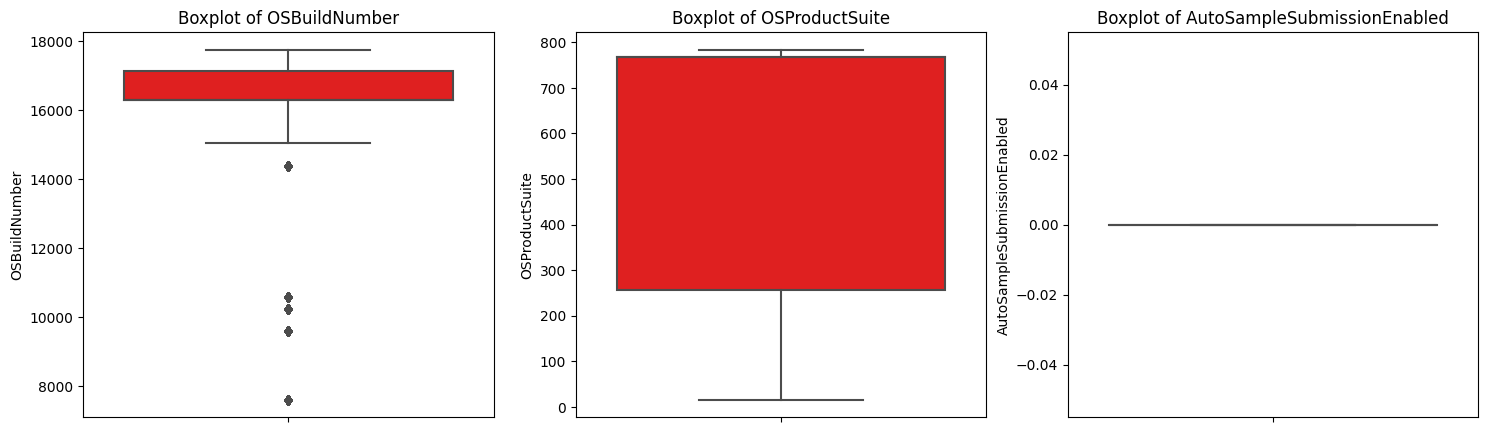

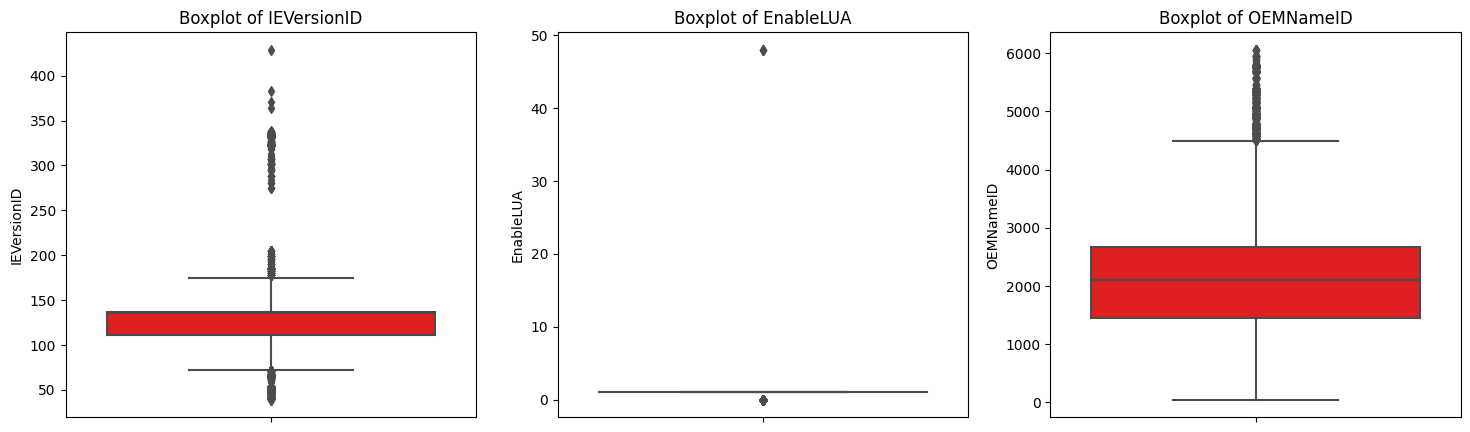

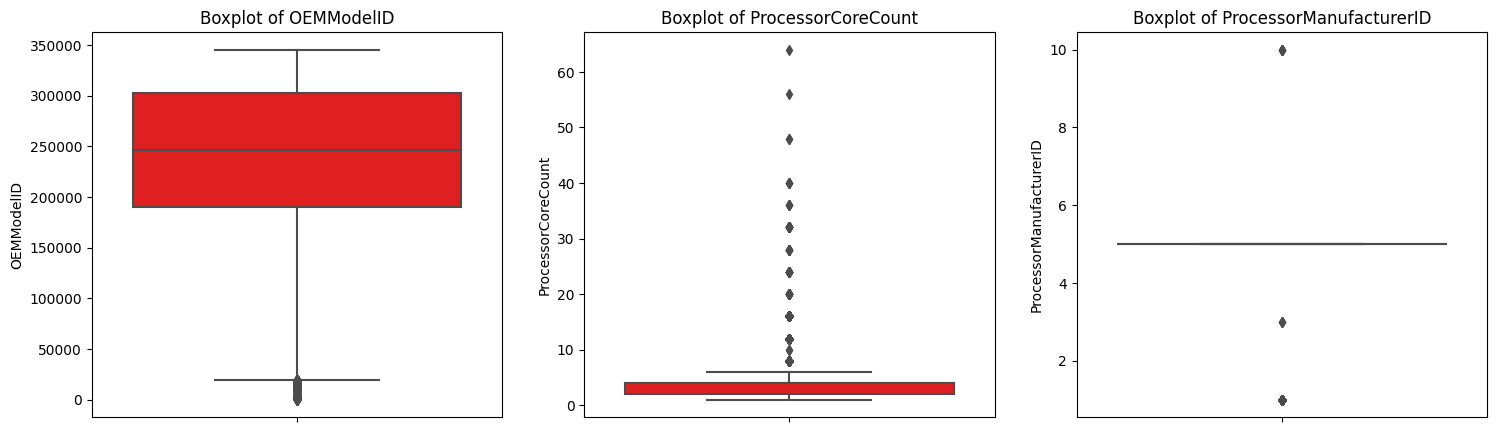

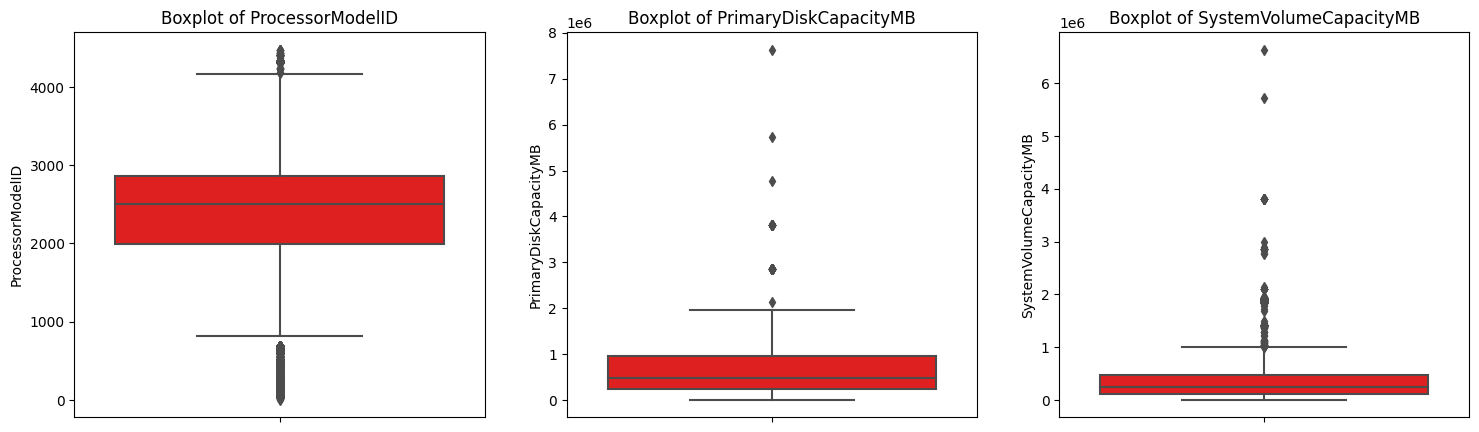

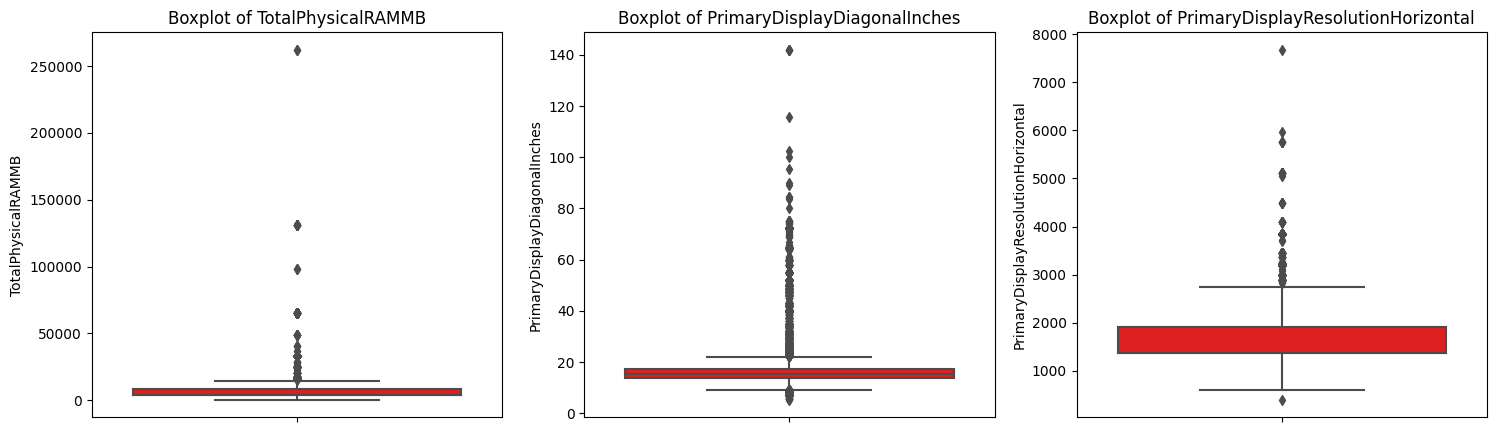

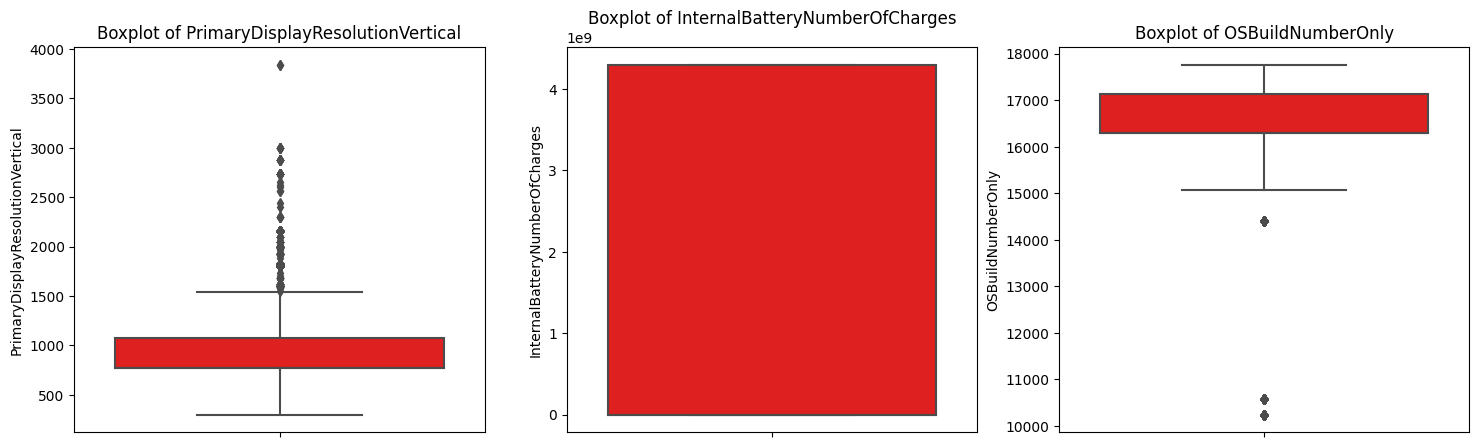

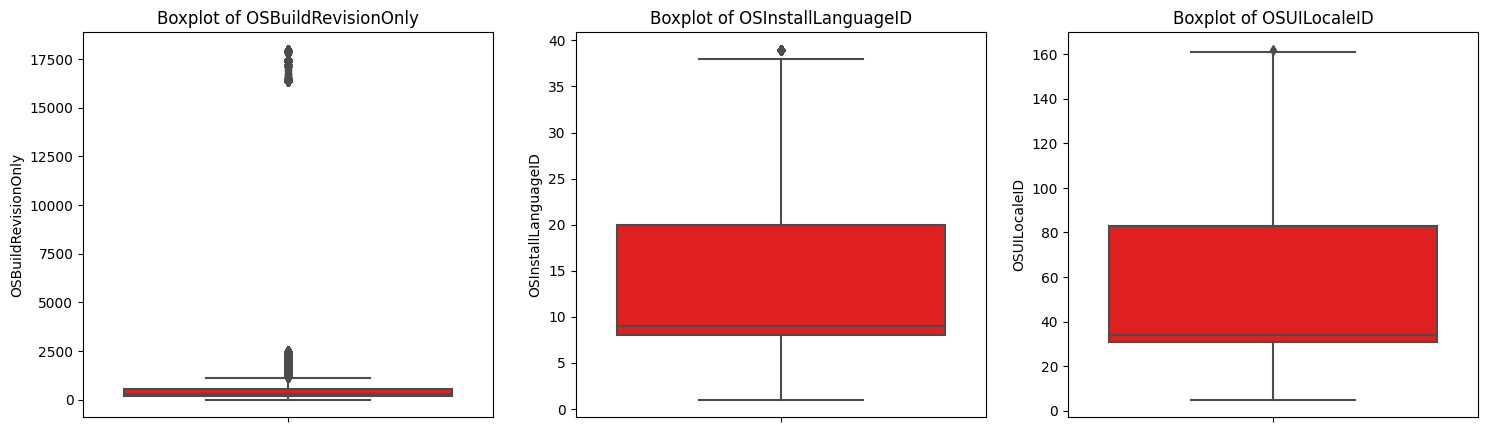

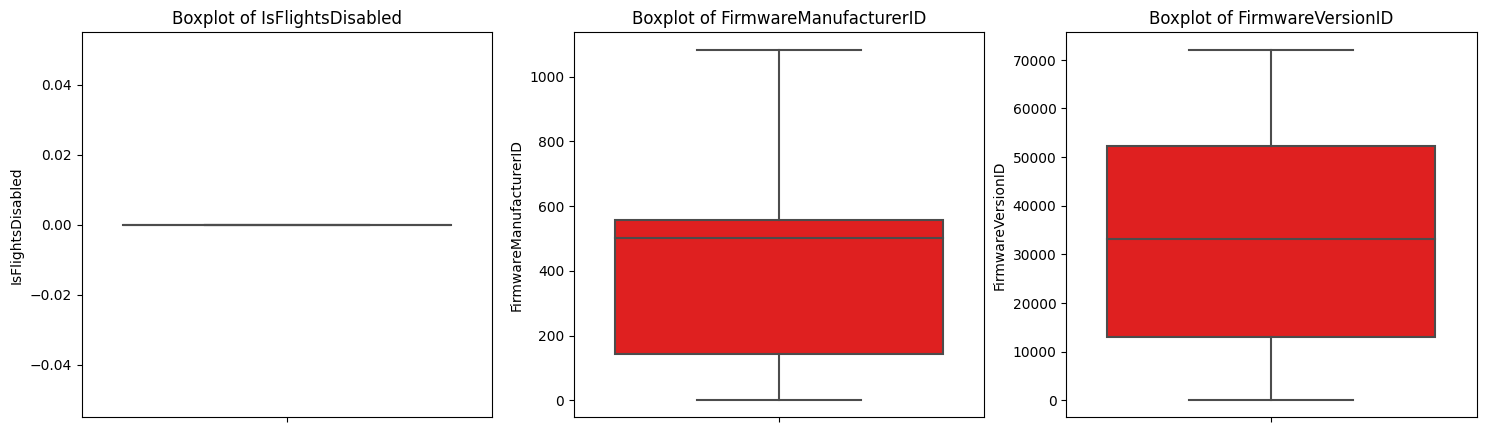

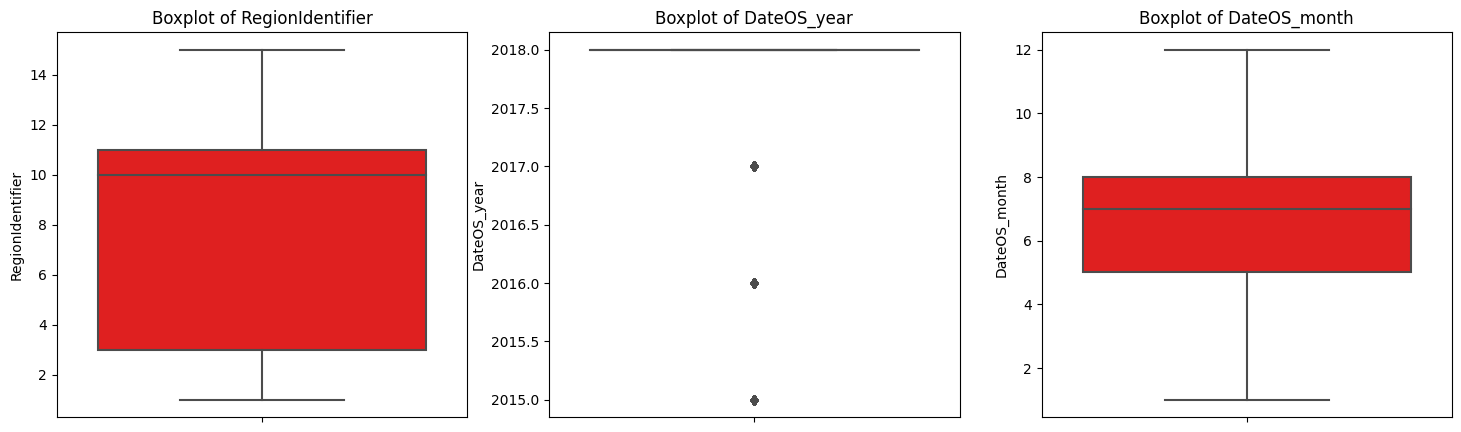

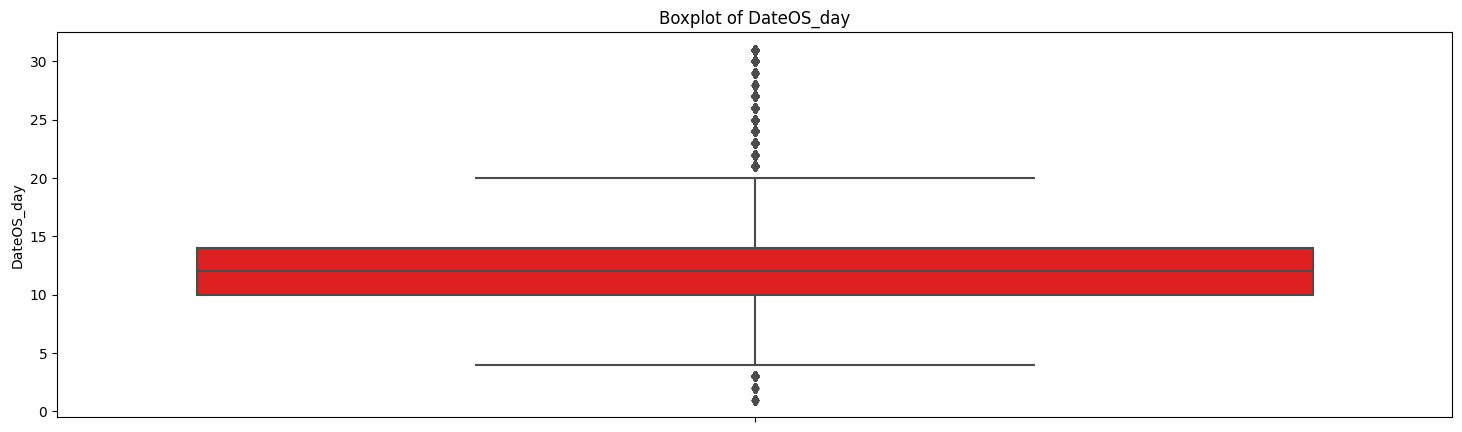

In [18]:
# Plot boxplots for numerical features
for i in range(0, len(numerical_features), 3):  
    cols = numerical_features[i:i+3]  # Take up to 3 columns at a time
    fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))  # Dynamically adjust subplot count
    
    if len(cols) == 1:  # If only 1 column left, axes is not a list
        axes = [axes]
    
    for j, col in enumerate(cols):  
        sns.boxplot(y=df_train[col].dropna(), color="red", ax=axes[j])  
        axes[j].set_title(f"Boxplot of {col}")
    
    plt.show()


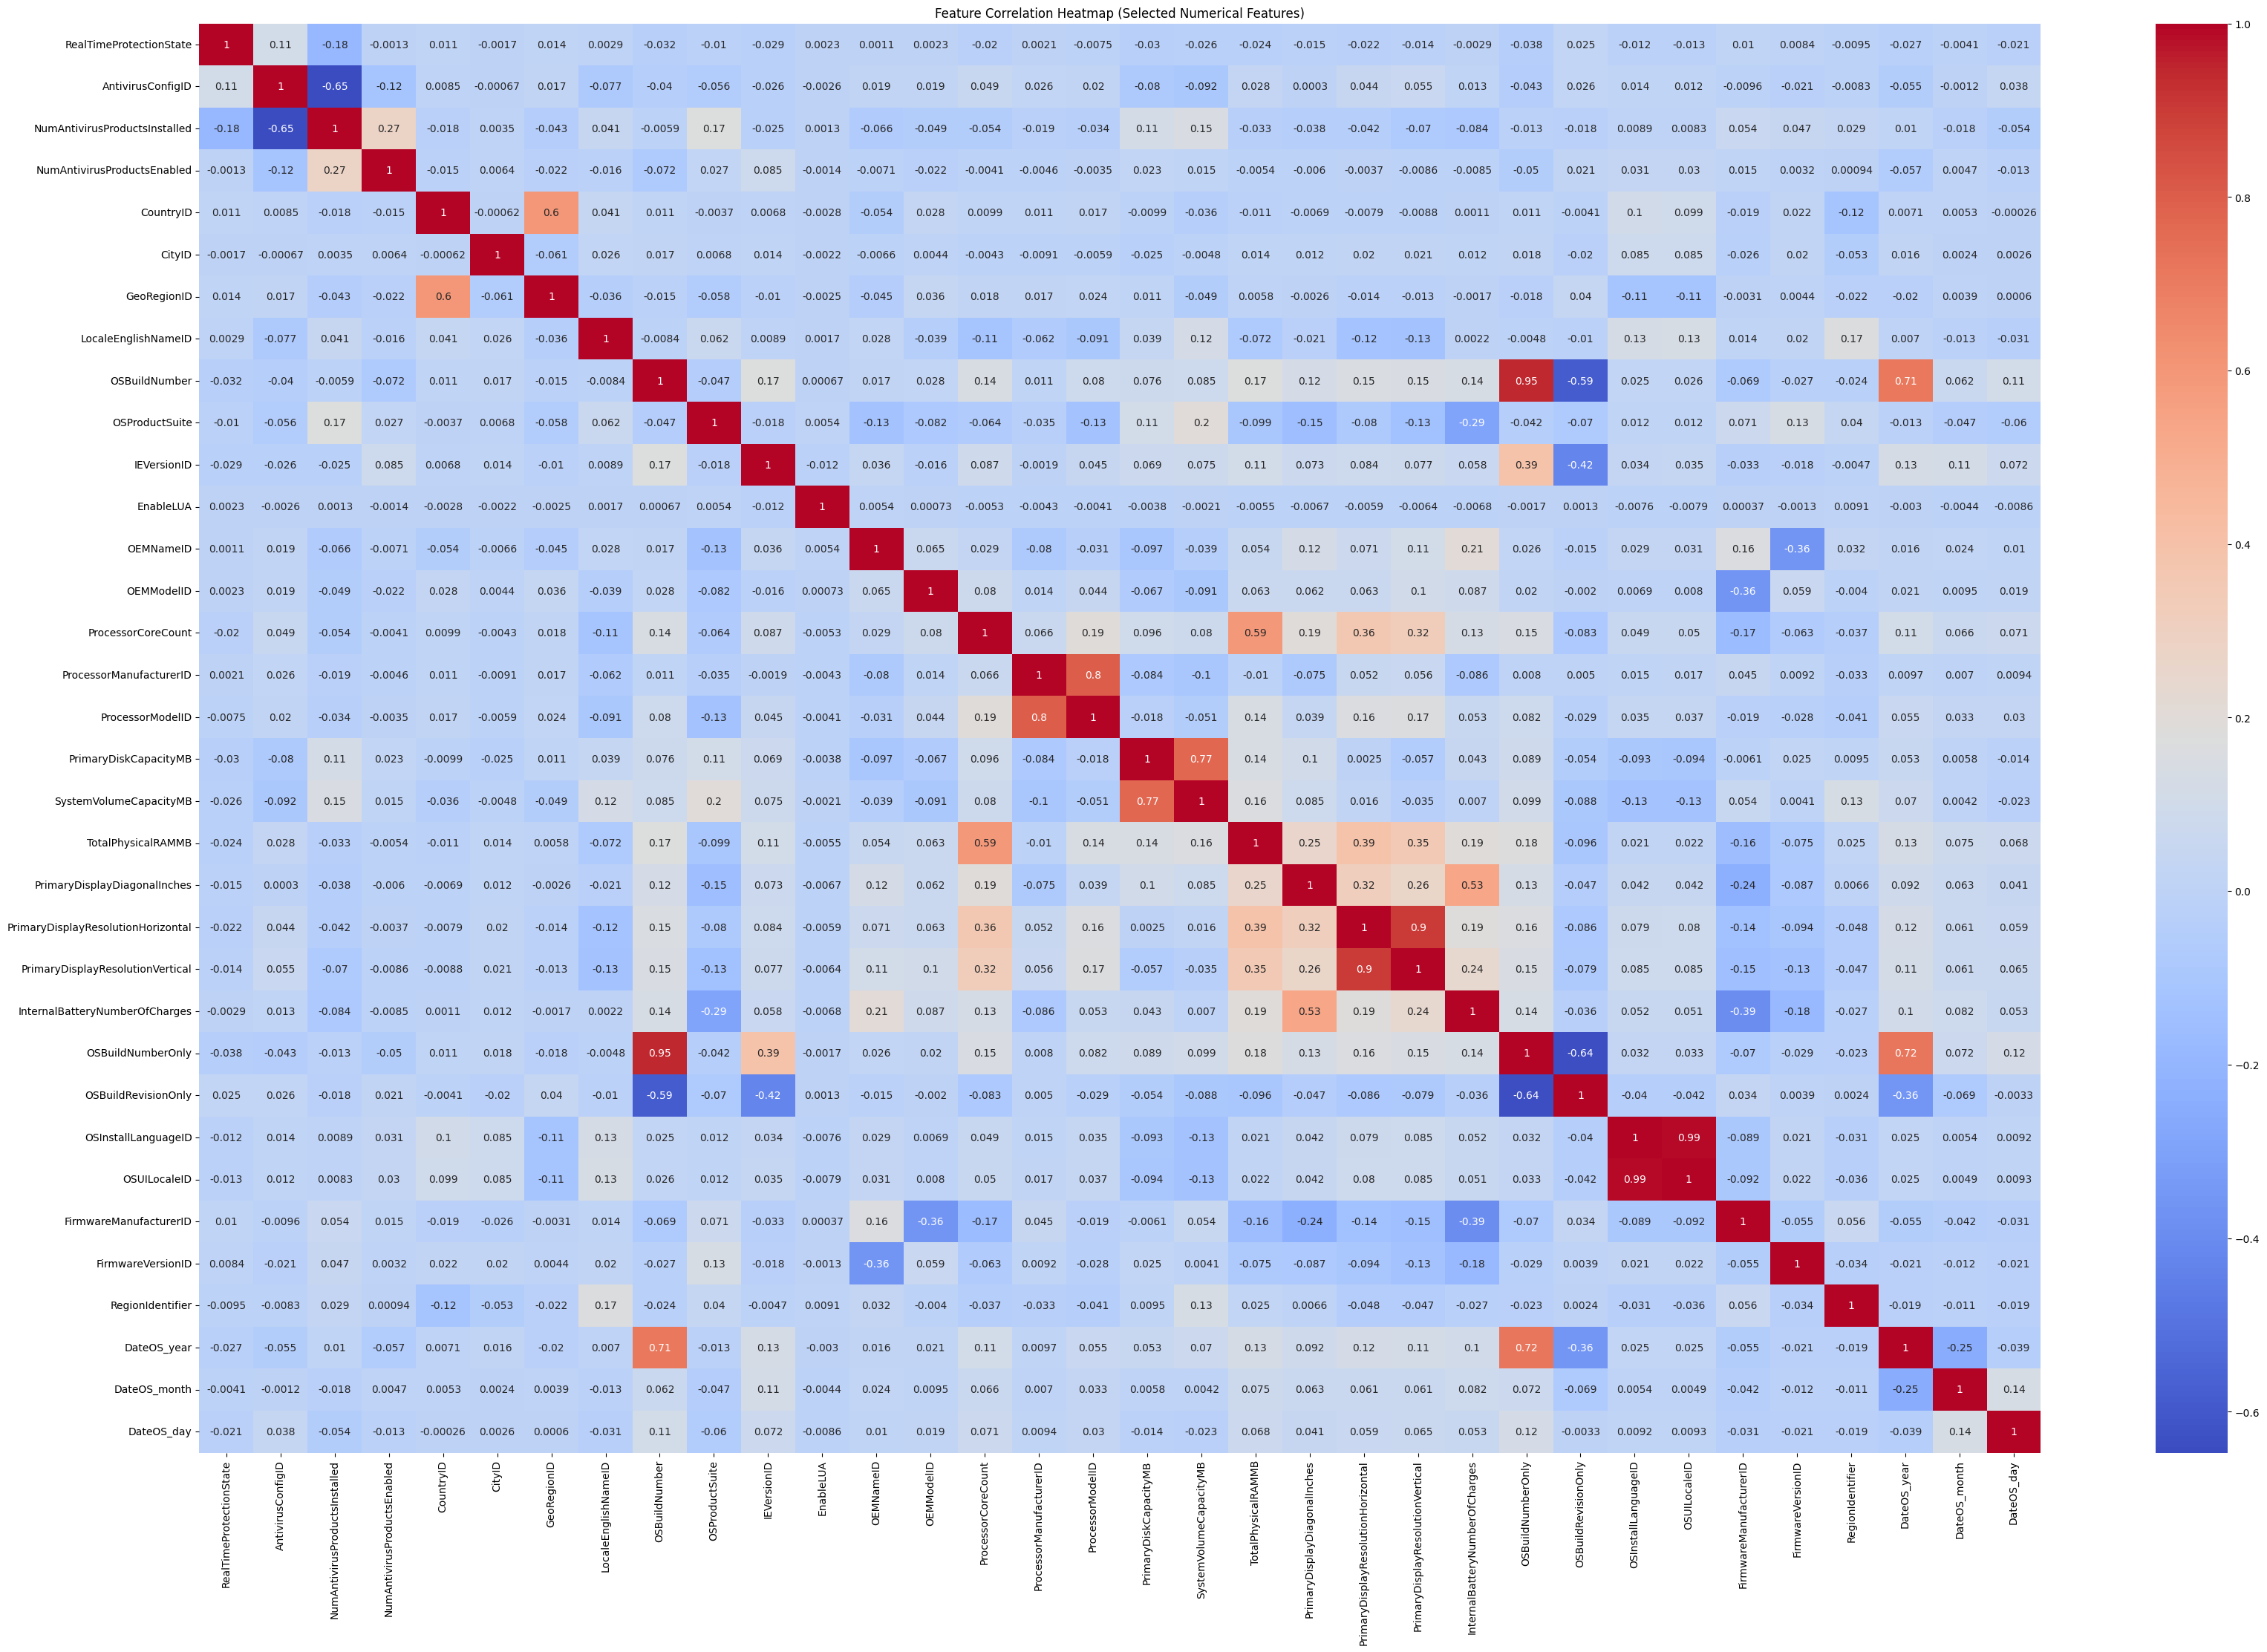

In [19]:
corr_matrix = df_train[numerical_features].corr()
corr_matrix = corr_matrix.loc[(corr_matrix.abs().sum(axis=1) > 0), (corr_matrix.abs().sum(axis=0) > 0)]
plt.figure(figsize=(40,25)) 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Selected Numerical Features)")
plt.show()

# Insights from Correlation Matrix
 1. Features like NumVirtualMachinesInstalled & NumAntivirusProductsInstalled can be removed to   avoid redundancy since they have a high correlation (>0.8).
 2. Features like GeoRegionID & ProcessorCoreCount have near-zero correlation, indicating they contribute independently. These features can be retained as they provide unique information.

In [20]:
df_train.shape, df_test.shape

((100000, 80), (10000, 79))

# PreProcessing

In [21]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_train[feature_list]  
y = df_train[label]  

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
y_train.head()

,target
75220,1
48955,1
44966,1
13568,0
92727,1


In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 79), (20000, 79), (80000, 1), (20000, 1))

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

In [25]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill NaNs with median
    ('scaler', StandardScaler())  # Standardize numerical features
])


In [26]:
binary_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))  # Fill NaNs with mode
])

# 🔹 Binary Categorical Features: Impute & Label Encode
binary_categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill NaNs with mode
    ('label_encoder', FunctionTransformer(lambda x: pd.DataFrame(x).apply(lambda col: col.astype('category').cat.codes)))
])

In [27]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill NaNs with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding for categorical features
])

In [28]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('bin_num', binary_numeric_pipeline, binary_numeric_features),
    ('bin_cat', binary_categorical_pipeline, binary_categorical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [29]:
X_train_processed = preprocessor.fit_transform(X_train).toarray() 
X_test_processed = preprocessor.transform(X_test).toarray() 


In [30]:
df_test_processed= preprocessor.transform(df_test).toarray()
df_test_processed=pd.DataFrame(df_test_processed)

In [31]:
X_train_processed_df = pd.DataFrame(X_train_processed)
X_test_processed_df = pd.DataFrame(X_test_processed)

In [32]:
X_train_processed_df.shape, X_test_processed_df.shape

((80000, 3397), (20000, 3397))

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [34]:
# Convert target variable to 1D array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()


In [35]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_processed_df, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [36]:
# Predict on Training & Test Data
y_test_pred = log_reg.predict(X_test_processed_df)


In [37]:
# Calculate Accuracy
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.6102


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)

# Train the model
rf_clf.fit(X_train_processed_df, y_train)

# Predict on Test Data
rf_pred = rf_clf.predict(X_test_processed_df)

# Evaluate Accuracy
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest Accuracy: 0.6154


In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=10, random_state=42, use_label_encoder=False, eval_metric="logloss")

# Train the model
xgb_clf.fit(X_train_processed_df, y_train)

# Predict on Test Data
xgb_pred = xgb_clf.predict(X_test_processed_df)

# Evaluate Accuracy
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")


XGBoost Accuracy: 0.6254


In [40]:
prediction =  xgb_clf.predict(df_test_processed)

In [41]:
prediction

array([1, 1, 1, ..., 0, 1, 0])

In [42]:
submission = pd.DataFrame({
"id": range(0,df_test.shape[0]),
"target": [x for x in prediction]
    
})

In [43]:
# import numpy as np
# from sklearn.dummy import DummyClassifier
# X=df_train.iloc[:,:-1]
# y=df_train['target']
# dummy_clf=DummyClassifier(strategy="most_frequent")
# dummy_clf.fit(X,y)
# y_pred=dummy_clf.predict(X)
# y_test_pred=dummy_clf.predict(df_test)
# submission = pd.DataFrame({
# "id": range(0,df_test.shape[0]),
# "target": [x for x in y_test_pred]
    
# })

In [44]:
submission.to_csv('submission.csv',index=False)